Imagen 'classic_car.png' cargada correctamente. Dimensiones originales: (559, 1024)


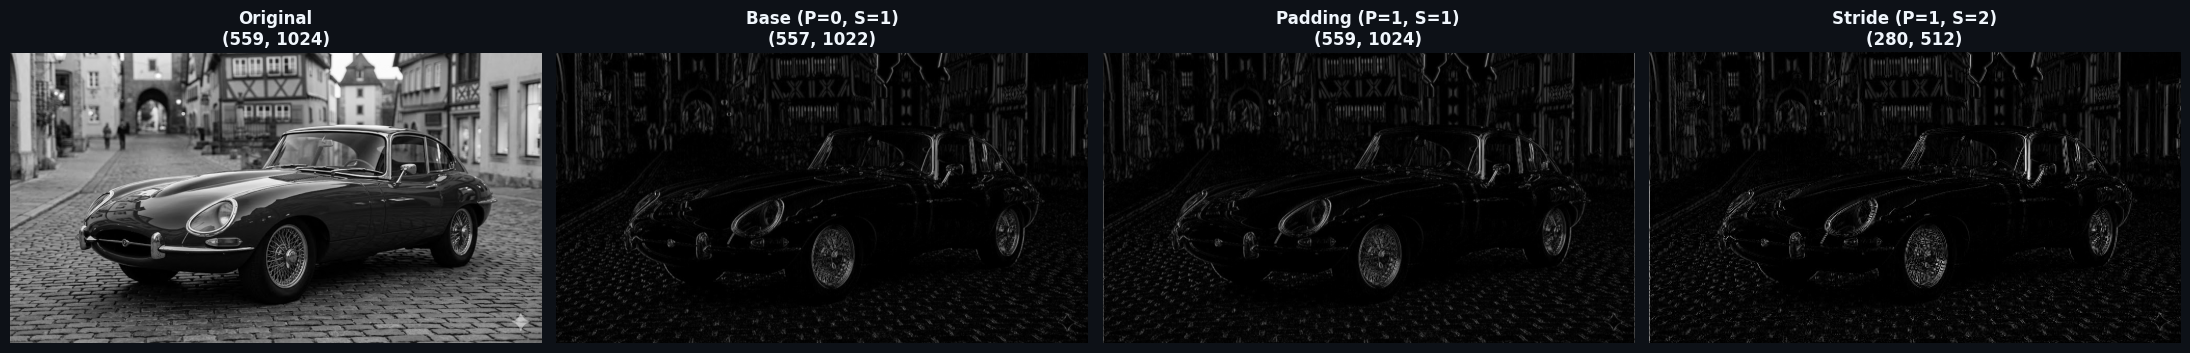

✅ Proceso completado con éxito. Dimensión de Salida con Stride 2: (280, 512)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

def convolucion_manual(imagen, kernel, padding=0, stride=1):
    # 1. Aplicación de Padding
    if padding > 0:
        # Se añaden ceros alrededor de la matriz de entrada
        matriz_entrada = np.pad(imagen, pad_width=padding, mode='constant', constant_values=0)
    else:
        matriz_entrada = imagen

    # 2. Obtención de dimensiones
    i_h, i_w = matriz_entrada.shape
    k_h, k_w = kernel.shape

    # 3. Cálculo de dimensiones de salida
    # O = floor((I - K + 2P) / S) + 1
    salida_h = int((i_h - k_h) / stride) + 1
    salida_w = int((i_w - k_w) / stride) + 1

    mapa_caracteristicas = np.zeros((salida_h, salida_w))

    # 4. Proceso de barrido
    for y in range(0, salida_h):
        for x in range(0, salida_w):
            # Selección de la submatriz según el Stride
            y_inicio = y * stride
            x_inicio = x * stride
            region = matriz_entrada[y_inicio : y_inicio + k_h, x_inicio : x_inicio + k_w]

            # Operación producto punto y suma (Convolución)
            mapa_caracteristicas[y, x] = np.sum(region * kernel)

    return mapa_caracteristicas

# --- SECCIÓN ACTUALIZADA: CARGA DE IMAGEN LOCAL ---
nombre_archivo_imagen = "classic_car.png"

# Carga de la imagen del auto clásico localmente
# se carga directamente en escala de grises para la convolución manual 2D
img_gray = cv2.imread(nombre_archivo_imagen, cv2.IMREAD_GRAYSCALE)

# Verificación de que la imagen se cargó correctamente
if img_gray is None:
    print(f"Error: No se pudo cargar el archivo '{nombre_archivo_imagen}'. Por favor, asegúrate de haberlo subido a tu entorno de Colab.")
else:
    # Normalización para que los valores estén entre 0 y 1
    img_gray = img_gray / 255.0
    print(f"Imagen '{nombre_archivo_imagen}' cargada correctamente. Dimensiones originales: {img_gray.shape}")

    # Detección de bordes
    kernel_sobel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])

    # EJECUCIÓN DE LAS TRES CONFIGURACIONES ( comparación)
    # 1. Base (Sin padding, Stride 1)
    res_base = convolucion_manual(img_gray, kernel_sobel, padding=0, stride=1)

    # 2. Con Padding (Mantiene tamaño original)
    res_pad = convolucion_manual(img_gray, kernel_sobel, padding=1, stride=1)

    # 3. Con Stride (Reduce tamaño a la mitad)
    res_stride = convolucion_manual(img_gray, kernel_sobel, padding=1, stride=2)

    # VISUALIZACIÓN DE EVIDENCIAS
    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    axes[0].imshow(img_gray, cmap='gray')
    axes[0].set_title(f"Original\n{img_gray.shape}")

    # se usa np.abs() para visualizar gradientes positivos y negativos como bordes
    axes[1].imshow(np.abs(res_base), cmap='gray')
    axes[1].set_title(f"Base (P=0, S=1)\n{res_base.shape}")

    axes[2].imshow(np.abs(res_pad), cmap='gray')
    axes[2].set_title(f"Padding (P=1, S=1)\n{res_pad.shape}")

    axes[3].imshow(np.abs(res_stride), cmap='gray')
    axes[3].set_title(f"Stride (P=1, S=2)\n{res_stride.shape}")

    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"✅ Proceso completado con éxito. Dimensión de Salida con Stride 2: {res_stride.shape}")